# ZEB Horizon (with VLP-16) demo

Notebook: Hannah Weiser, 2026

In this demo, we demonstrate how a system like the ZEB Horizon can be implemented, a sensor with multiple 2D scanners (transceivers/channels), an internal rotation (in HELIOS terminology "rotating head") and an additional rotation of the entire scanner.

The demo contains two surveys, one for a static simulation (scanner at a single location) and one for a dynamic simulation (scanner moving between waypoints). To model the rotation of the entire scanner, we use interpolated trajectories.

In [1]:
from IPython.display import Code
from pathlib import Path
import helios
from helios.utils import display_xml
import numpy as np
import matplotlib.pyplot as plt

## Scanner

The ZEB Horizon uses a VLP-16 scanner. Let's have a look how this scanner is configured in the HELIOS++ scanner specification.

In [2]:
scanner = helios.scanner_from_name("vlp16")

In [3]:
Code(
    display_xml(
        Path(helios.utils.get_asset_directories()[-1]) / "scanners_tls.xml", "vlp16"
    )
)

<scanner id="vlp16" accuracy_m="0.03" beamDivergence_rad="0.0007" name="Velodyne VLP-16" optics="rotating" pulseFreqs_Hz="18750" pulseLength_ns="5" rangeMin_m="0.09144" rangeMax_m="100" scanAngleMax_deg="1" scanAngleEffectiveMax_deg="1" scanFreqMin_Hz="0" scanFreqMax_Hz="0" wavelength_nm="905" maxNOR="2" headRotatePerSecMax_deg="7200">

    <headRotateAxis x="0" y="0" z="1" />
    <FWFSettings beamSampleQuality="3" />  <!-- set to one for fast simulations -->
    <channels>
      <channel id="0">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-15" />
        </beamOrigin>
      </channel>
      <channel id="1">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="1" />
        </beamOrigin>
      </channel>
      <channel id="2">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-13" />
        </beamOrigin>
      </channel>
      <channel id="3">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="3" />
        </beamOrigin>
      </channel>
      <channel id="4">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-11" />
        </beamOrigin>
      </channel>
      <channel id="5">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="5" />
        </beamOrigin>
      </channel>
      <channel id="6">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-9" />
        </beamOrigin>
      </channel>
      <channel id="7">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="7" />
        </beamOrigin>
      </channel>
      <channel id="8">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-7" />
        </beamOrigin>
      </channel>
      <channel id="9">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="9" />
        </beamOrigin>
      </channel>
      <channel id="10">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-5" />
        </beamOrigin>
      </channel>
      <channel id="11">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="11" />
        </beamOrigin>
      </channel>
      <channel id="12">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-3" />
        </beamOrigin>
      </channel>
      <channel id="13">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="13" />
        </beamOrigin>
      </channel>
      <channel id="14">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="-1" />
        </beamOrigin>
      </channel>
      <channel id="15">
        <beamOrigin x="0" y="0" z="0">
          <rot axis="x" angle_deg="15" />
        </beamOrigin>
      </channel>
    </channels>

  </scanner>

The scanner is defined with `rotating` optics, but the values for `scanFreqMin_Hz` and `scanFreqMax_Hz` (both "0") show that this feature is not used in this implementation. Additionaly, the `scanAngleMax_deg` is set to a value of 1. Subsequently, 16 channels are defined, each with their individual rotations. As the scan plane is not used (default would be the y/z-Plane, see the wiki) and only a single direction per pulse is given, a simple rotation upwards or downwards about the `x` axis is sufficient. The values for the angles are taken from the user manual of the VLP-16.

The `pulseFreq_hz` in the `<scannerSettings >` is coming from the max. measurement rate of the VLP-16 (300,000 pts/sec). The `headRotatePerSecMax_deg` value corresponds to what Velodyne refers to as scan frequency - this is not to be confused with the within-scan line `scanFreq_hz` we use for e.g. RIEGL-type TLS sensors. The user manual gives a value of 1200 rpm as a maximum rotation speed of the motor, equivalent to 20 rotations per seconds (20 Hz scan frequency), or a rotation speed `headRotatePerSecMax_deg` of 7200 (20 * 360°).

## Scene

Let us now use a simple scene (just containing a cube with 100 m side length, centered around the origin) to carry out two surveys:

In [4]:
box = helios.ScenePart.from_obj("../data/sceneparts/basic/box/box100.obj")
scene = helios.StaticScene([box])

## Static survey

For the static survey, we place the scanner at a single location and let it scan for 10 seconds. We assume a roll rotation (rotation about the y-axis) of the entire scanner of 180°/s (0.5 Hz). The internal rotation of the channels is set to 10 Hz.

In [ ]:
# Build structured numpy array for the trajectory
times = np.arange(0, 10, 0.25)
xs = np.zeros(len(times))
ys = np.zeros(len(times))
zs = np.zeros(len(times))
roll = 2 * np.pi * times / 2  # vary roll (in radians) with time so one rotation is finished after 2 s
pitch = np.zeros(len(times)) 
yaw = np.zeros(len(times)) 

trajectory = np.zeros(
    len(xs),
    dtype={
        "names": ("t", "roll", "pitch", "yaw", "x", "y", "z"),
        "formats": ("f8", "f8", "f8", "f8", "f8", "f8", "f8"),
    },
)
trajectory["x"] = xs
trajectory["y"] = ys
trajectory["z"] = zs
trajectory["t"] = times
trajectory["roll"] = roll
trajectory["pitch"] = pitch
trajectory["yaw"] = yaw

# Create platform from trajectory
platform = helios.Platform.load_interpolate_platform(
    trajectory=trajectory,
    platform_file="data/platforms.xml",
    platform_id="horizon_linearpath",
    interpolation_method="CANONICAL",
    sync_gps_time=True,
)

# Define scanner settings
scanner_settings = helios.ScannerSettings(
    pulse_frequency=18_750 * helios.units.Hz,  # 300,000 Hz / 16 channels
    scan_frequency=0 * helios.units.Hz,  # since each channel is a line scanner
    scan_angle=1 * helios.units.deg,
    head_rotation="3600 deg/s",  # 10 Hz
    trajectory_time_interval=0.06 * helios.units.s,
)

# Build survey
survey = helios.Survey(
    scanner=scanner, platform=platform, scene=scene
)

# Add survey leg with trajectory settings
trajectory_settings_leg = helios.platforms.TrajectorySettings(
    teleport_to_start=True, start_time=0, end_time=times[-1]  # full trajectory time
)
survey.add_leg(
    scanner_settings=scanner_settings, trajectory_settings=trajectory_settings_leg
)

We are now ready to run the simulation.

In [6]:
pc, traj = survey.run()

Legs:   0%|          | 0/1 [00:00<?, ?leg/s]

Current leg time: 0.00s [00:00, ?s/s]

Let's display a 3D plot for all points recorded in the first 1/10th second (one internal rotation).

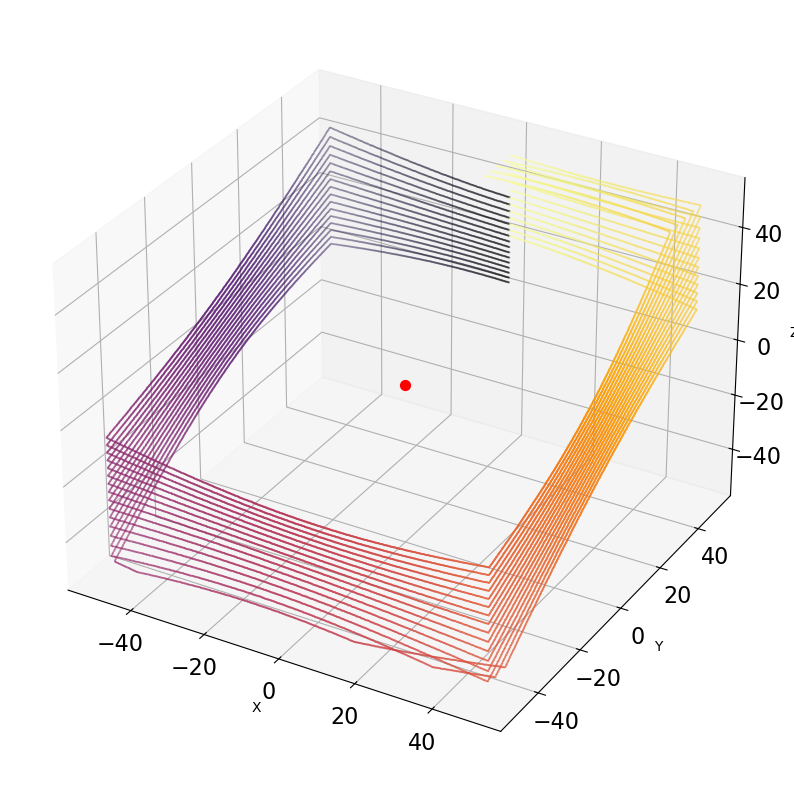

In [7]:
cmap = "inferno"
point_size = 0.2

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection="3d")

# select all points recorded in the first 1/10th second
sel = pc["gps_time"] <= min(pc["gps_time"]) + 0.1
pc_filtered = pc["position"][sel]
gps_time_filtered = pc["gps_time"][sel]

ax.scatter(
    pc_filtered[:, 0],
    pc_filtered[:, 1],
    pc_filtered[:, 2],
    s=point_size,
    c=gps_time_filtered,
    cmap=cmap
)
ax.scatter([0], [0], [0], s=50, c="red")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.tick_params(labelsize=16)
plt.show()

And now the same plot, but for a full rotation of the entire scanner (2 seconds). 

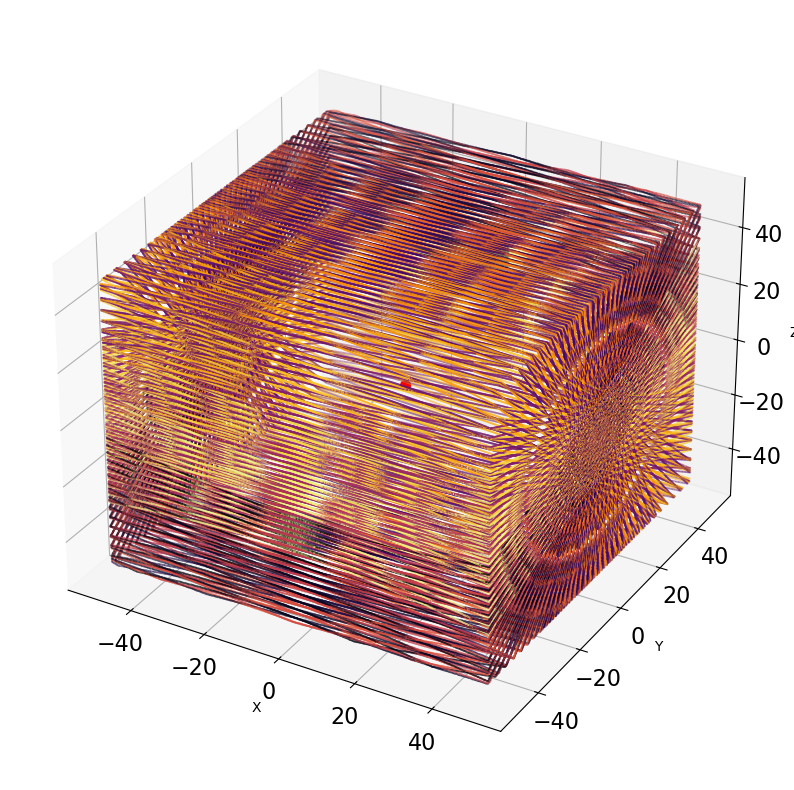

In [8]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection="3d")

# select all points recorded in the first second
sel = pc["gps_time"] <= min(pc["gps_time"]) + 2
pc_filtered = pc["position"][sel]
gps_time_filtered = pc["gps_time"][sel]

ax.scatter(
    pc_filtered[:, 0],
    pc_filtered[:, 1],
    pc_filtered[:, 2],
    s=point_size,
    c=gps_time_filtered,
    cmap=cmap
)
ax.scatter([0], [0], [0], s=50, c="red")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.tick_params(labelsize=16)
plt.show()

## Dynamic survey

We now want to simulate a moving scanner. We use the same scene as before, but move the scanner from `(-20, 0, 0)` to `(20, 0, 0)` over a course of 10 seconds (4 m/s). We do this by overwriting the x-values in the trajectory array and then reload the trajectory.

In [9]:
scanner = helios.scanner_from_name("vlp16")
trajectory["x"] = np.linspace(-20, 20, len(times))
platform = helios.Platform.load_interpolate_platform(
    trajectory=trajectory,
    platform_file="data/platforms.xml",
    platform_id="horizon_linearpath",
    interpolation_method="CANONICAL",
    sync_gps_time=True,
)

In [10]:
survey = helios.Survey(scanner=scanner, platform=platform, scene=scene)
trajectory_settings_leg = helios.platforms.TrajectorySettings(
    teleport_to_start=True, start_time=0, end_time=times[-1]
)
survey.add_leg(
    scanner_settings=scanner_settings, trajectory_settings=trajectory_settings_leg
)

In [11]:
pc, traj = survey.run()

Legs:   0%|          | 0/1 [00:00<?, ?leg/s]

Current leg time: 0.00s [00:00, ?s/s]

Now let's display a 3D plot for all points recorded in the first 1/10th second (one internal rotation). In a second plot, we plot the points recorded in the last 1/10th second (last internal rotation).

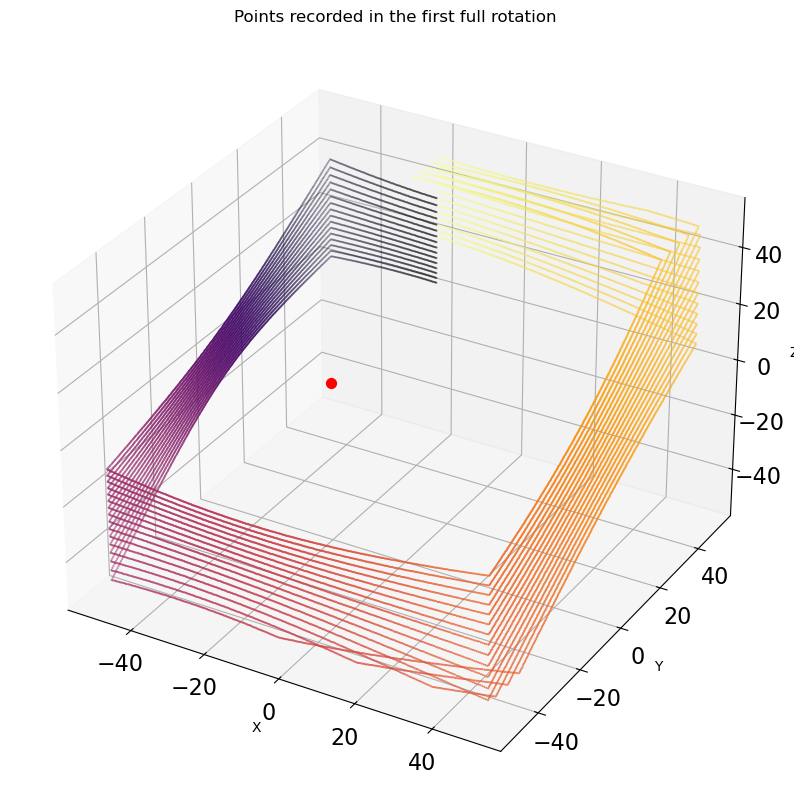

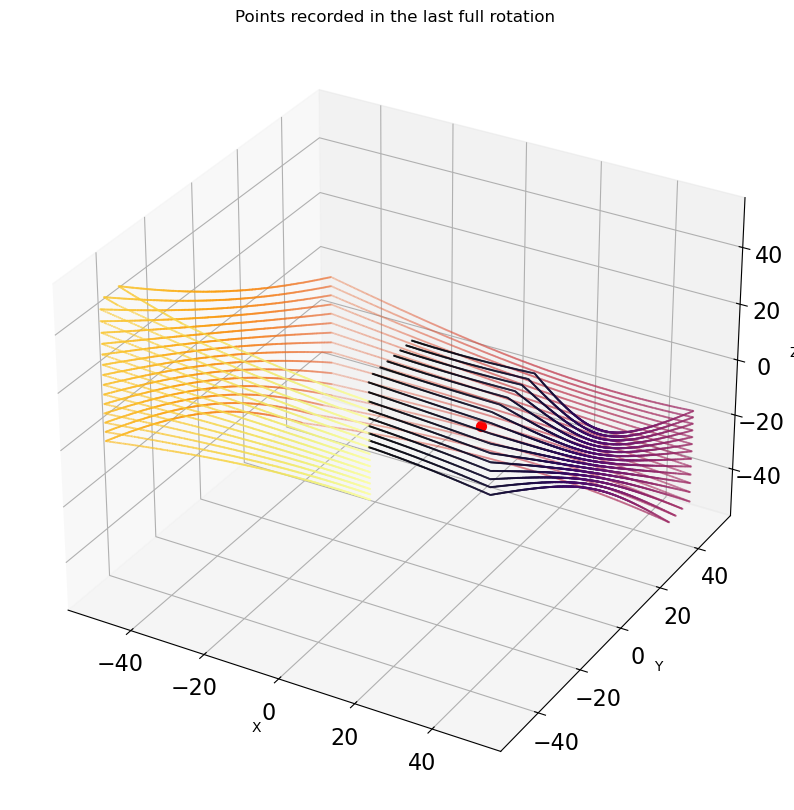

In [12]:
for fun in (min, max):

    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(projection="3d")

    # select all points recorded in the first/last 1/10 second
    sel_idx = abs(pc["gps_time"] - fun(pc["gps_time"])) <= 0.1

    pc_filtered = pc["position"][sel_idx]
    gps_time_filtered = pc["gps_time"][sel_idx]

    ax.scatter(
        pc_filtered[:, 0],
        pc_filtered[:, 1],
        pc_filtered[:, 2],
        s=point_size,
        c=gps_time_filtered,
        cmap=cmap
    )
    ax.scatter([-20 if fun is min else 20], [0], [0], s=50, c="red")

    ax.tick_params(labelsize=16)
    plt.title(
        "Points recorded in the "
        + ("first " if fun is min else "last ")
        + "full rotation"
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

Next, we plot the point cloud and the trajectory for different portions of the survey, split up by time.

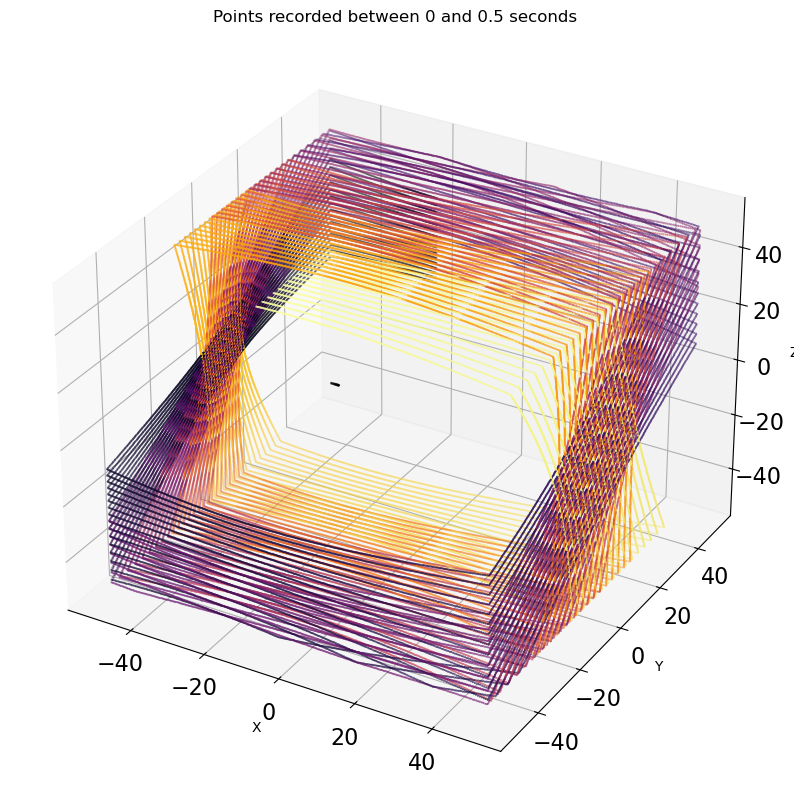

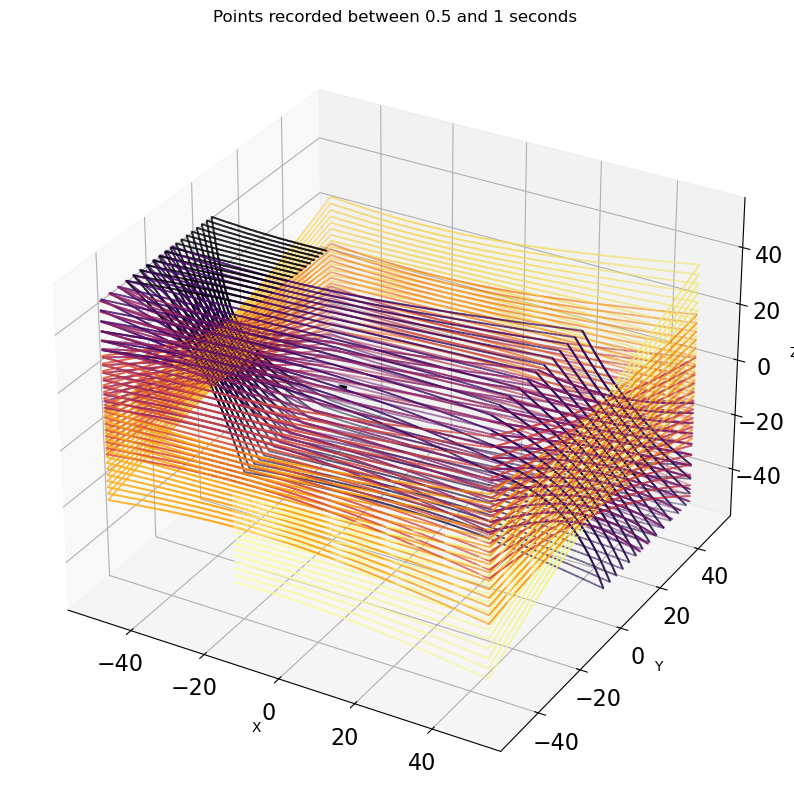

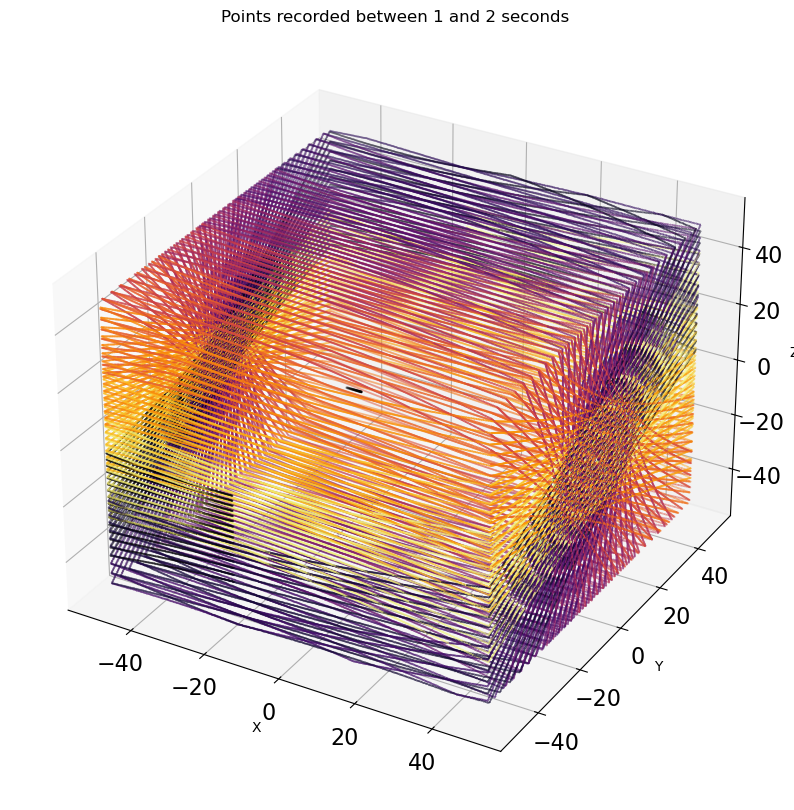

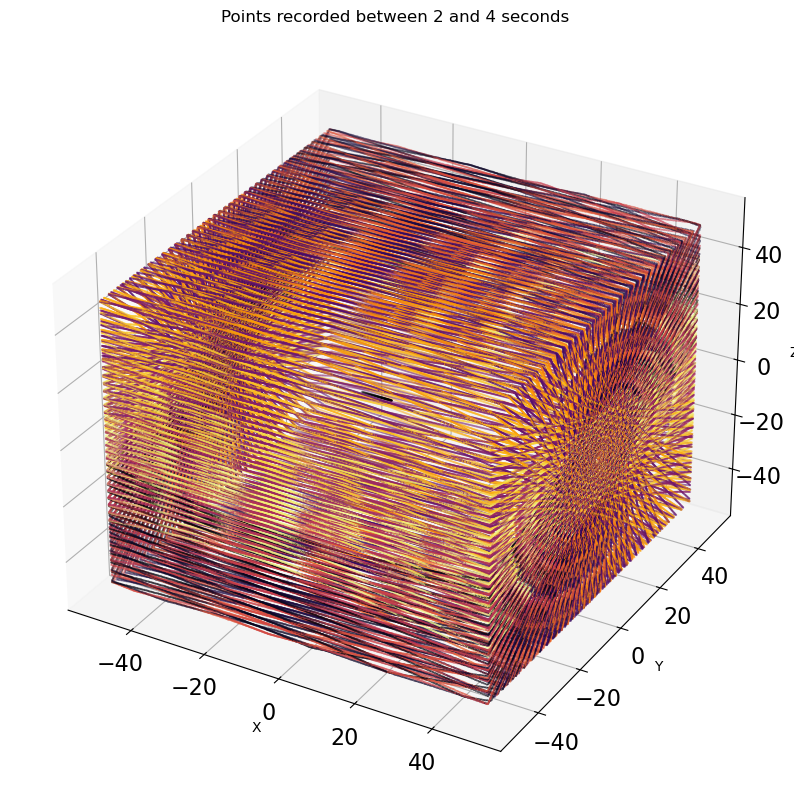

In [13]:
timestamps = [0, 0.5, 1, 2, 4]
for i, sec in enumerate(timestamps[:-1]):
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(projection="3d")

    # select all points recorded in the first second
    sel = (pc["gps_time"] <= min(pc["gps_time"]) + timestamps[i+1]) & (pc["gps_time"] >= min(pc["gps_time"]) + timestamps[i])
    sel_traj = (traj["gps_time"] <= min(traj["gps_time"]) + timestamps[i+1]) & (traj["gps_time"] >= min(traj["gps_time"]) + timestamps[i])
    pc_filtered = pc["position"][sel]
    gps_time_filtered = pc["gps_time"][sel]
    traj_filtered = traj["position"][sel_traj]
    gps_time_traj_filtered = traj["gps_time"][sel_traj]

    ax.scatter(
        pc_filtered[:, 0],
        pc_filtered[:, 1],
        pc_filtered[:, 2],
        s=point_size,
        c=gps_time_filtered,
        cmap=cmap
    )
    ax.scatter(
        traj_filtered[:, 0],
        traj_filtered[:, 1],
        traj_filtered[:, 2],
        s=1,
        c="black",
    )
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.tick_params(labelsize=16)
    ax.set_title(f"Points recorded between {timestamps[i]} and {timestamps[i+1]} seconds")
    plt.show()